In [188]:
from discretize import TreeMesh
from discretize.utils import active_from_xyz
import matplotlib.pyplot as plt
import numpy as np
import simpeg.potential_fields as pf
from simpeg import (
    data,
    data_misfit,
    directives,
    inverse_problem,
    inversion,
    maps,
    optimization,
    regularization,
    utils,
)
from simpeg.utils import io_utils, plot2Ddata

# Common Python functionality
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import os

## Setup

## 1. import mesh and model

In [189]:
# Load mesh from local directory
mesh_file = "mesh_tutorial.ubc"
mesh = TreeMesh.read_UBC(mesh_file)

In [190]:
# Load true geology model from local directory
true_geology_file = "geology_true.mod"
true_geology = mesh.read_model_UBC(true_geology_file)

## 2. plot mesh and model

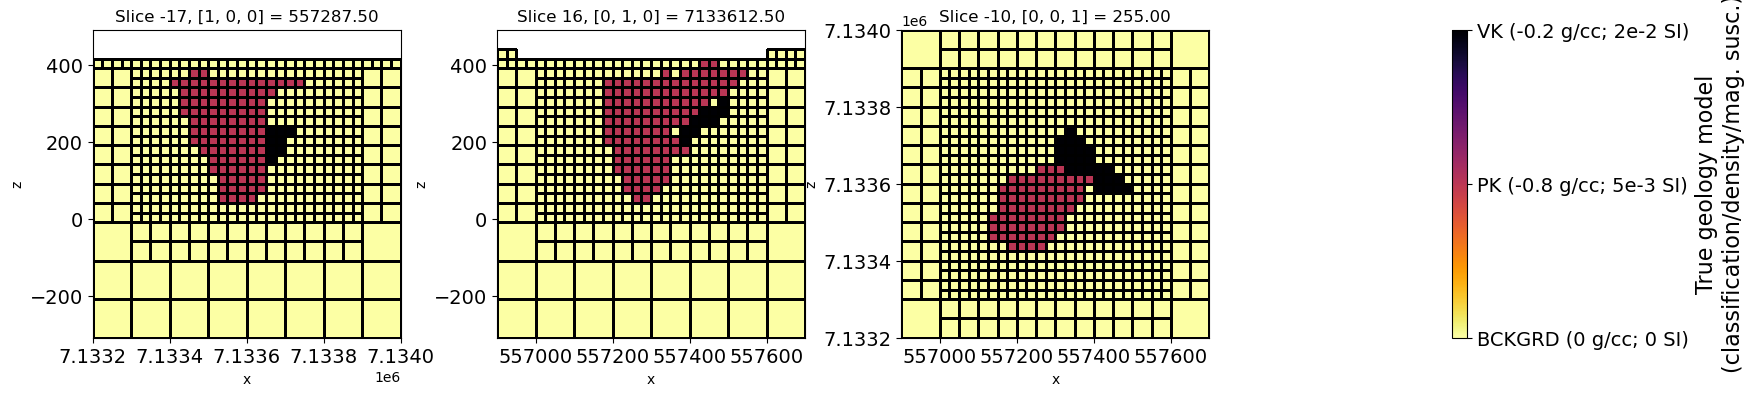

In [191]:
# Plot true geology model
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
ticksize, labelsize = 14, 16
for _, axx in enumerate(ax):
    axx.set_aspect(1)
    axx.tick_params(labelsize=ticksize)
mesh.plot_slice(
    true_geology,
    normal="X",
    ax=ax[0],
    ind=-17,
    clim=[0, 2],
    pcolor_opts={"cmap": "inferno_r"},
    grid=True,
)
mesh.plot_slice(
    true_geology,
    normal="Y",
    ax=ax[1],
    clim=[0, 2],
    pcolor_opts={"cmap": "inferno_r"},
    grid=True,
)
geoplot = mesh.plot_slice(
    true_geology,
    normal="Z",
    ax=ax[2],
    clim=[0, 2],
    ind=-10,
    pcolor_opts={"cmap": "inferno_r"},
    grid=True,
)
geocb = plt.colorbar(geoplot[0], cax=ax[3], ticks=[0, 1, 2])
geocb.set_label(
    "True geology model\n(classification/density/mag. susc.)", fontsize=labelsize
)
geocb.set_ticklabels(
    ["BCKGRD (0 g/cc; 0 SI)", "PK (-0.8 g/cc; 5e-3 SI)", "VK (-0.2 g/cc; 2e-2 SI)"]
)
geocb.ax.tick_params(labelsize=ticksize)
ax[3].set_aspect(10)
plt.show()


C:\Users\30562\AppData\Local\Temp\ipykernel_33588\3339215290.py:55: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  p.show()


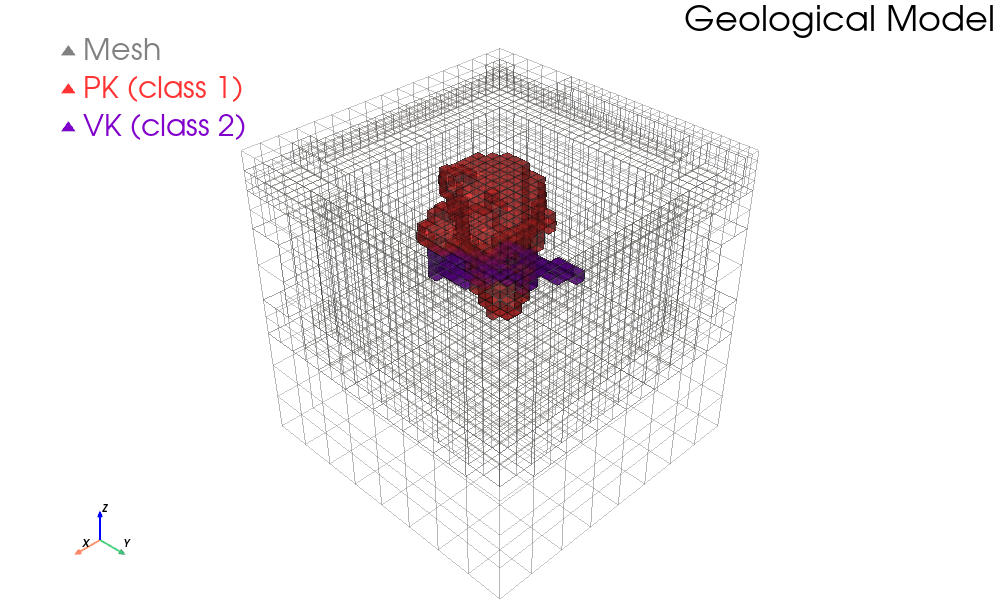

In [192]:
# 3D 可视化 - 网格线框 + 离散颜色 (pyvista)
import pyvista as pv

# 只提取矿体单元 (class 1: PK, class 2: VK，不显示背景 class 0)
mask_orebody = (true_geology > 0)  # True for ore bodies
cell_ids = np.where(mask_orebody)[0]

# 从 mesh 转换为 UnstructuredGrid
ug = mesh.to_vtk()  # TreeMesh 转 VTK

# 提取矿体单元及其对应的类别值
ug_orebody = ug.extract_cells(cell_ids)
geology_orebody = true_geology[cell_ids]

# 将类别数据附加到提取的网格
ug_orebody["geology"] = geology_orebody

# 离散颜色映射 (PK=1: 红色, VK=2: 紫色)
geology_colors = {
    1: [1.0, 0.2, 0.2],  # PK - 红色
    2: [0.5, 0.0, 0.8],  # VK - 紫色
}

p = pv.Plotter(window_size=(1000, 600))
p.background_color = "white"  # 白色背景

# 添加整个网格的边框作为参考框架（半透明灰色）
p.add_mesh(
    ug,
    style="wireframe",
    color="gray",
    line_width=0.1,
    opacity=0.2,
    label="Mesh",
)

# 为两个矿体分别添加网格线框
for ore_class, color in geology_colors.items():
    mask = geology_orebody == ore_class
    cell_subset = ug_orebody.extract_cells(np.where(mask)[0])
    label = f"PK (class {ore_class})" if ore_class == 1 else f"VK (class {ore_class})"
    p.add_mesh(
        cell_subset,
        color=color,
        show_edges=True,
        edge_color="black",
        line_width=0.5,
        opacity=0.7,
        label=label,
    )

p.add_axes(line_width=2)
p.add_legend(loc="upper left")
p.add_text("Geological Model", position="upper_right", font_size=14)
p.show()

In [193]:
# 导出 VTK 文件

# 创建输出目录
output_dir = "vtk_output"
os.makedirs(output_dir, exist_ok=True)

# 导出完整网格（带地质分类）
mesh_file_path = os.path.join(output_dir, "geological_mesh_full.vtk")
ug.save(mesh_file_path)
print(f"✓ 完整网格已保存: {mesh_file_path}")

# 导出矿体网格（仅矿体）
orebody_file_path = os.path.join(output_dir, "ore_bodies.vtk")
ug_orebody.save(orebody_file_path)
print(f"✓ 矿体网格已保存: {orebody_file_path}")

print(f"\n所有文件保存在: {os.path.abspath(output_dir)}")
print(f"可用 ParaView 或其他 VTK 查看器打开这些文件")

✓ 完整网格已保存: vtk_output\geological_mesh_full.vtk
✓ 矿体网格已保存: vtk_output\ore_bodies.vtk

所有文件保存在: c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Geological_model_Inversion\vtk_output
可用 ParaView 或其他 VTK 查看器打开这些文件


## 3. import gravity data

In [194]:
# Load gravity data from local directory
data_grav_file = "gravity_data.obs"
data_grav = io_utils.read_grav3d_ubc(data_grav_file)

C:\Users\30562\AppData\Local\Temp\ipykernel_33588\1136830129.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


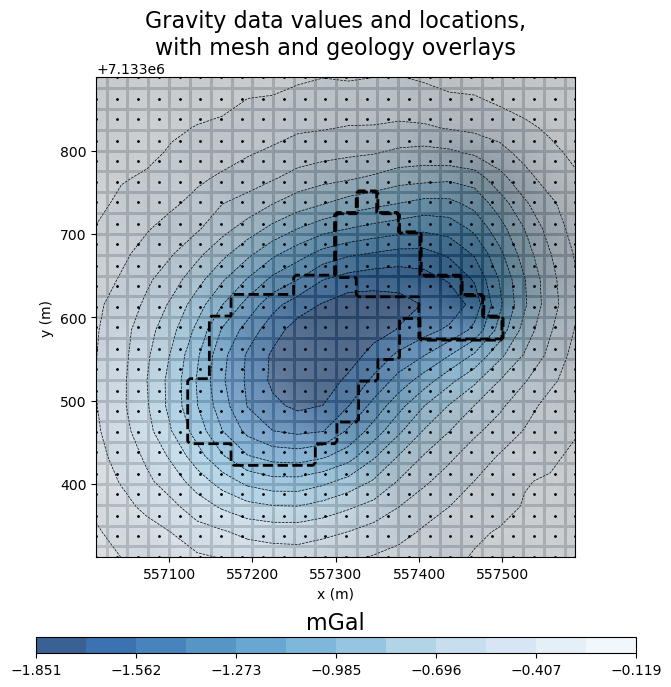

In [195]:
# plot gravity data and mesh
fig = plt.figure(figsize=(10, 8))

# main axis
ax = fig.add_axes([0.1, 0.2, 0.8, 0.6])

mesh.plot_slice(
    np.ones(mesh.nC),
    normal="Z",
    ind=int(-10),
    grid=True,
    pcolor_opts={"cmap": "Greys"},
    ax=ax,
)

mm = utils.plot2Ddata(
    data_grav.survey.receiver_locations,
    -data_grav.dobs,
    ax=ax,
    level=True,
    nx=20,
    ny=20,
    dataloc=True,
    ncontour=12,
    shade=True,
    contourOpts={"cmap": "Blues_r", "alpha": 0.8},
    levelOpts={"colors": "k", "linewidths": 0.5, "linestyles": "dashed"},
)

ax.set_aspect(1)
ax.set_title(
    "Gravity data values and locations,\nwith mesh and geology overlays",
    fontsize=16,
)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

ax.set_xlim(
    [
        data_grav.survey.receiver_locations[:, 0].min(),
        data_grav.survey.receiver_locations[:, 0].max(),
    ],
)
ax.set_ylim(
    [
        data_grav.survey.receiver_locations[:, 1].min(),
        data_grav.survey.receiver_locations[:, 1].max(),
    ],
)

# overlay true geology model for comparison
indz = -10
indslicezplot = mesh.gridCC[:, 2] == mesh.cell_centers_z[indz]

utils.plot2Ddata(
    mesh.gridCC[indslicezplot][:, [0, 1]],
    true_geology[indslicezplot],
    nx=200,
    ny=200,
    contourOpts={"alpha": 0},
    clim=[0, 2],
    ax=ax,
    level=True,
    ncontour=2,
    levelOpts={"colors": "k", "linewidths": 2, "linestyles": "--"},
    method="nearest",
)

# colorbar axis
cax = fig.add_axes([0.2, 0.08, 0.6, 0.02])
plt.colorbar(mm[0], cax=cax, orientation="horizontal")
cax.set_title("mGal", fontsize=16)

plt.tight_layout()
plt.show()

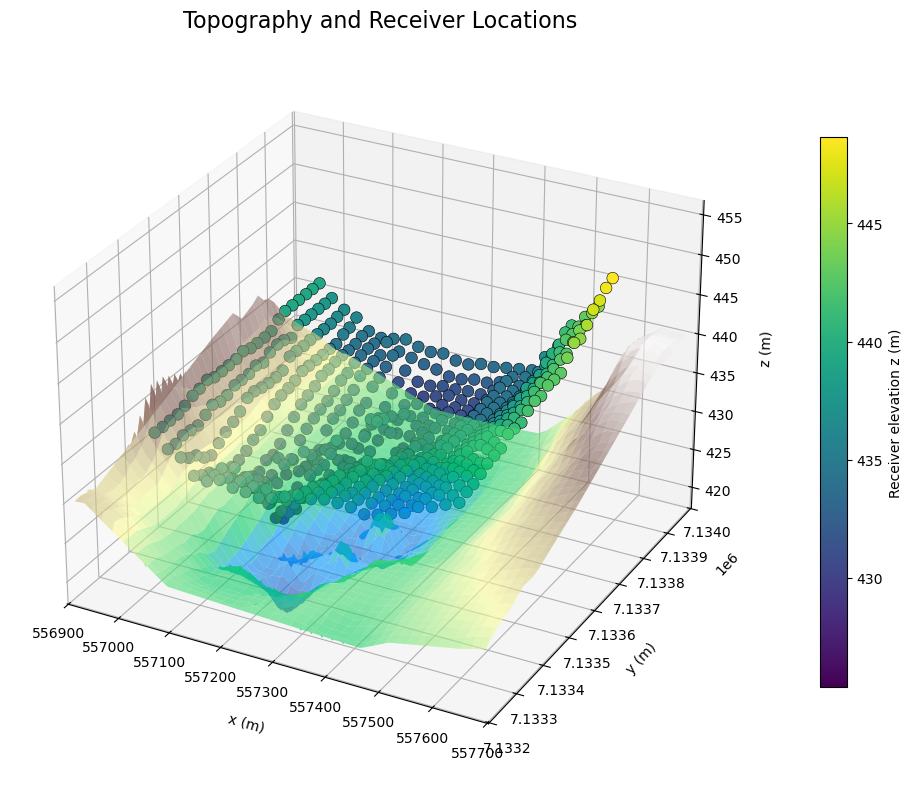

In [196]:
# Zoomed-in 3D view: topography + receiver locations
rx = data_grav.survey.receiver_locations

# Ensure topography is available even when cells are run out of order
if "topo" not in globals():
    topo_file = "CDED_Lake_warp.xyz"
    topo = np.genfromtxt(topo_file, skip_header=1)

# Receiver bounds with padding
x_min, x_max = rx[:, 0].min(), rx[:, 0].max()
y_min, y_max = rx[:, 1].min(), rx[:, 1].max()
z_min, z_max = rx[:, 2].min(), rx[:, 2].max()

x_pad = 0.20 * (x_max - x_min)
y_pad = 0.20 * (y_max - y_min)
z_pad = max(5.0, 0.35 * (z_max - z_min))

x_lim = (x_min - x_pad, x_max + x_pad)
y_lim = (y_min - y_pad, y_max + y_pad)
z_lim = (z_min - z_pad, z_max + z_pad)

# Keep only local topography around receivers
topo_mask = (
    (topo[:, 0] >= x_lim[0]) & (topo[:, 0] <= x_lim[1]) &
    (topo[:, 1] >= y_lim[0]) & (topo[:, 1] <= y_lim[1])
)
topo_local = topo[topo_mask]

# Fallback in case local selection is too small
if topo_local.shape[0] < 20:
    topo_local = topo

# Interpolate local topography onto a regular grid
x_topo, y_topo, z_topo = topo_local[:, 0], topo_local[:, 1], topo_local[:, 2]
xi = np.linspace(x_topo.min(), x_topo.max(), 120)
yi = np.linspace(y_topo.min(), y_topo.max(), 120)
XI, YI = np.meshgrid(xi, yi)
interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
ZI = interp(XI, YI)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Local topography surface
ax.plot_surface(
    XI, YI, ZI,
    cmap="terrain",
    linewidth=0,
    antialiased=True,
    alpha=0.60,
    shade=True,
    vmin=np.nanmin(ZI),
    vmax=np.nanmax(ZI),
)

# Receivers (larger markers for visibility)
sc = ax.scatter(
    rx[:, 0], rx[:, 1], rx[:, 2],
    s=70,
    c=rx[:, 2],
    cmap="viridis",
    edgecolors="k",
    linewidths=0.4,
    depthshade=False,
    zorder=5,
    label="Receivers",
)

ax.set_xlim(x_lim)
ax.set_ylim(y_lim)
ax.set_zlim(z_lim)
ax.set_xlabel("x (m)", labelpad=10)
ax.set_ylabel("y (m)", labelpad=10)
ax.set_zlabel("z (m)", labelpad=10)
ax.view_init(elev=28, azim=-62)

cbar = plt.colorbar(sc, ax=ax, pad=0.08, shrink=0.75)
cbar.set_label("Receiver elevation z (m)")

# Figure-level title stays centered even with colorbar
fig.suptitle("Topography and Receiver Locations", x=0.4, y=0.98, fontsize=16)

plt.tight_layout()
plt.show()

## 4. import topography

In [197]:
# Load Topo from local directory
topo_file = "CDED_Lake_warp.xyz"
topo = np.genfromtxt(topo_file, skip_header=1)

In [198]:
# find the active cells
active_cells = active_from_xyz(mesh, topo, "CC")

# Create active map to go from reduced set to full
plotting_Map = maps.InjectActiveCells(mesh, active_cells, np.nan)
n_active = int(active_cells.sum())

# Identity map for density-only inversion
model_Map = maps.IdentityMap(nP=n_active)

## 5. Inversion

## a. Baseline WLS Inversion

In [199]:
# Starting/Reference Models
starting_model = 1e-6 * np.ones(n_active)
reference_model = np.zeros_like(starting_model)

In [200]:
# Simulation
simulation_grav = pf.gravity.simulation.Simulation3DIntegral(
    survey=data_grav.survey,
    mesh=mesh,
    rhoMap=model_Map,
    active_cells=active_cells,
    engine="choclo",
)

# Data misfit
dmis_L2 = data_misfit.L2DataMisfit(data=data_grav, simulation=simulation_grav)


# Regularization
reg_L2 = regularization.WeightedLeastSquares(
    mesh,
    active_cells=active_cells,
    length_scale_x=1.0, # smoothness in x direction 如果有地质先验，比如层状构造往往垂向变化比水平变化更剧烈，那有时会把不同方向设成不同值。
    length_scale_y=1.0,
    length_scale_z=1.0,
    reference_model=reference_model, # zero reference model
    reference_model_in_smooth=False, #参考模型只用于 smallness 项，不用于 smoothness 项
)


# Optimizaiton
opt_L2 = optimization.InexactGaussNewton(
    maxIter=100, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_L2, reg_L2, opt_L2)


# Directives
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=10)
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)
target_misfit = directives.TargetMisfit(chifact=1.0)

directives_list_L2 = [
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
]

Define and Run the Inversion

In [201]:
# Here we combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run inversion
recovered_model = inv_L2.run(starting_model)


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 576.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.09e+00  4.35e+06  4.67e-04  4.35e+06                                 
   1  1.09e+00  5.47e+05  8.18e+05  1.44e+06    1.61e+06      0              
   2  5.47e-01  2.40e+05  1.21e+06  9.01e+05    2.18e+05      0              
   3  2.74e-01  9.40e+04  1.57e+06  5.25e+05    1.26e+05      0              
   4  1.37e-01  3.35e+04  1.88e+06  2.90e+05    6.82e+04      0              
   5  6.84e-02  1.14e+04  2.10e+06  1.55e+05    3.58e+04      0              
   6  3.42e-02  3.99e+03  2.24e+06  8.07e+04    1.84e+04      0              
   7  1.71e-02  1.61e+03  2.34e+06  4.16e+04    9.37e+03      0              
   8  8.55e-03  8.30e+02  2.40e+06  2.13e+04    4.61e+03      0              
   9  4.28e-03  5.32e+02  2.45e+06  1.10e+04    2.64e+03      0

In [202]:
# Predicted data with final recovered model.
dpred = inv_prob_L2.dpred

# Data
dobs = data_grav.dobs
receiver_locations = data_grav.survey.receiver_locations

Plot result

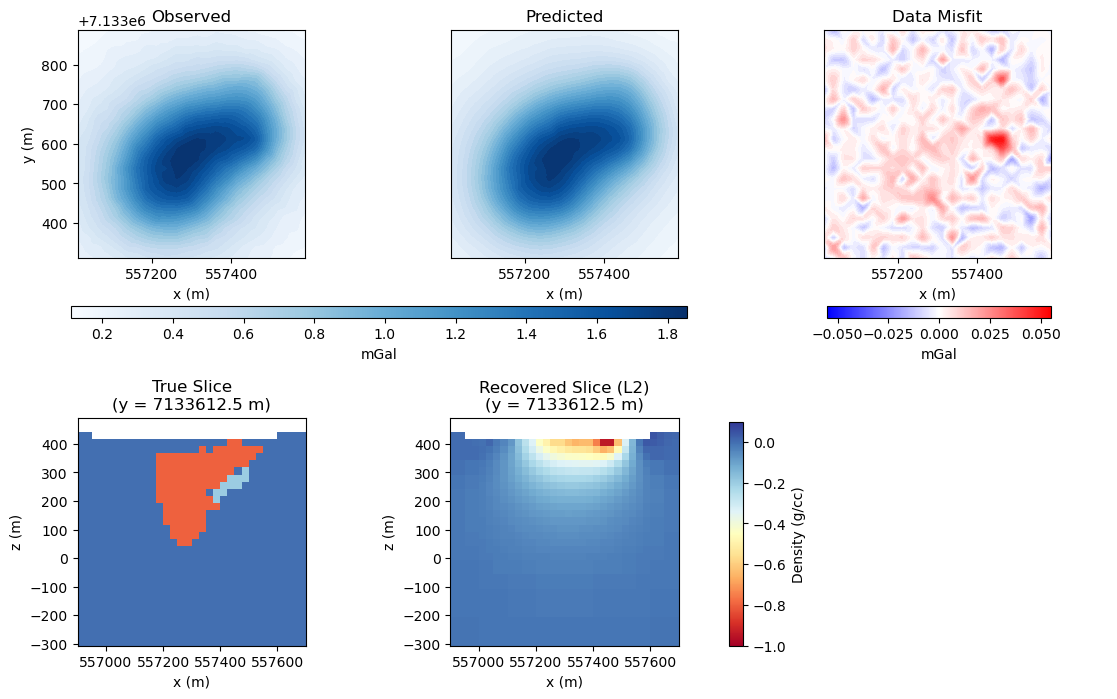

In [ ]:
# Observed / Predicted / Misfit + True/Recovered slices (clean 2x3 layout)
data_array_l2 = np.c_[dobs, dpred, dobs - dpred]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.7, wspace=0.10)

# Top row (keep three data panels)
ax_data = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
plot_title = ["Observed", "Predicted", "Data Misfit"]

norm_data = mpl.colors.Normalize(
    vmin=np.min(data_array_l2[:, :2]),
    vmax=np.max(data_array_l2[:, :2]),
)
norm_misfit = mpl.colors.Normalize(
    vmin=-np.max(np.abs(data_array_l2[:, 2])),
    vmax=np.max(np.abs(data_array_l2[:, 2])),
)

plot2Ddata(
    receiver_locations,
    data_array_l2[:, 0],
    ax=ax_data[0],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[0].set_title(plot_title[0])
ax_data[0].set_xlabel("x (m)")
ax_data[0].set_ylabel("y (m)")

plot2Ddata(
    receiver_locations,
    data_array_l2[:, 1],
    ax=ax_data[1],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[1].set_title(plot_title[1])
ax_data[1].set_xlabel("x (m)")
ax_data[1].set_yticks([])

plot2Ddata(
    receiver_locations,
    data_array_l2[:, 2],
    ax=ax_data[2],
    ncontour=30,
    contourOpts={"cmap": "bwr", "norm": norm_misfit},
)
ax_data[2].set_title(plot_title[2])
ax_data[2].set_xlabel("x (m)")
ax_data[2].set_yticks([])

# Shared colorbar for observed/predicted data
cax_data = fig.add_axes([0.16, 0.52, 0.44, 0.015])
sm_data = mpl.cm.ScalarMappable(norm=norm_data, cmap=mpl.cm.Blues)
cbar_data = fig.colorbar(sm_data, cax=cax_data, orientation="horizontal")
cbar_data.set_label("mGal")

# Dedicated colorbar for data misfit (third panel)
cax_misfit = fig.add_axes([0.7, 0.52, 0.16, 0.015])
sm_misfit = mpl.cm.ScalarMappable(norm=norm_misfit, cmap=mpl.cm.bwr)
cbar_misfit = fig.colorbar(sm_misfit, cax=cax_misfit, orientation="horizontal")
cbar_misfit.set_label("mGal")

# Bottom row: true and recovered model slices
ax_true = fig.add_subplot(gs[1, 0])
ax_rec = fig.add_subplot(gs[1, 1])
ax_empty = fig.add_subplot(gs[1, 2])
ax_empty.axis("off")

rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2
rho_true_active = rho_true[active_cells]

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

# Fix model color scale across all inversion cases when available
shared_models = [rho_true_active]
for name in [
    "recovered_model",
    "recovered_IRLS_model",
    "recovered_depth_model",
    "recovered_irls_sens_model",
    "recovered_irls_reweighted_model",
]:
    if name in globals():
        shared_models.append(globals()[name])
shared_model_values = np.concatenate(shared_models)
norm_model = mpl.colors.Normalize(
    vmin=np.min(shared_model_values),
    vmax=np.max(shared_model_values),
)

mesh.plot_slice(
    plotting_Map * rho_true_active,
    normal="Y",
    ind=y_idx,
    ax=ax_true,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_true.set_title(f"True Slice\n(y = {y_val:.1f} m)")
ax_true.set_xlabel("x (m)")
ax_true.set_ylabel("z (m)")
ax_true.set_aspect(1)

mesh.plot_slice(
    plotting_Map * recovered_model,
    normal="Y",
    ind=y_idx,
    ax=ax_rec,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_rec.set_title(f"Recovered Slice (L2)\n(y = {y_val:.1f} m)")
ax_rec.set_xlabel("x (m)")
ax_rec.set_ylabel("z (m)")
ax_rec.set_aspect(1)

# Small model colorbar (does not occupy the last grid cell)
cax_model = fig.add_axes([0.63, 0.11, 0.01, 0.28])
sm_model = mpl.cm.ScalarMappable(norm=norm_model, cmap=mpl.cm.RdYlBu)
cbar_model = fig.colorbar(sm_model, cax=cax_model, orientation="vertical")
cbar_model.set_label("Density (g/cc)")

plt.show()

## b. IRLS Baseline (Sparse-norm, original data_grav)

Sparse-norm regularization

In [204]:
# Data misfit for IRLS baseline (using original data_grav, not reweighted)
dmis_irls = data_misfit.L2DataMisfit(data=data_grav, simulation=simulation_grav)

# Regularization for IRLS
dh = min(mesh.h[0].min(), mesh.h[1].min(), mesh.h[2].min())
print(dh)

reg_irls = regularization.Sparse(
    mesh,
    active_cells=active_cells,
    alpha_s=dh**-2,
    alpha_x=1,
    alpha_y=1,
    alpha_z=1,
    reference_model=reference_model,
    reference_model_in_smooth=False,
    norms=[0, 1, 1, 1],
)

25.0


In [205]:
# Optimization for IRLS
opt_irls = optimization.ProjectedGNCG(
    maxIter=100, lower=-1.0, upper=1.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

# Directives for IRLS
starting_beta_irls = directives.BetaEstimate_ByEig(beta0_ratio=10)
update_jacobi_irls = directives.UpdatePreconditioner(update_every_iteration=True)
update_irls = directives.UpdateIRLS(
    cooling_factor=2,
    cooling_rate=1,
    chifact_start=1.0,
    f_min_change=1e-4,
    max_irls_iterations=25,
)

directives_list_irls = [
    update_irls,
    starting_beta_irls,
    update_jacobi_irls,
]

Define and Run the Inversion

In [206]:
# Inverse problem for IRLS
inv_prob_irls = inverse_problem.BaseInvProblem(dmis_irls, reg_irls, opt_irls)
inv_irls = inversion.BaseInversion(inv_prob_irls, directives_list_irls)
recovered_IRLS_model = inv_irls.run(starting_model)


Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  6.49e+02  4.35e+06  7.46e-07  4.35e+06                         0           inf          inf                
   1  6.49e+02  5.16e+05  1.36e+03  1.40e+06    1.03e+02      0      6        7.32e-03     1.18e+04              
   2  3.24e+02  2.24e+05  1.98e+03  8.66e+05    1.03e+02      0      6        9.38e-03     1.97e+03              
   3  1.62e+02  8.70e+04  2.56e+03  5.02e+05    1.02e+02      0      5        9.33e-03     1.12e+03              
   4  8.11e+01  3.08e+04  3.03e+03  2.77e+05    1.02e+02      0      6        6.16e-03     3.99e+02              
   5  4.05e+01  1.05e+04  3.37e+03  1.47e+05    

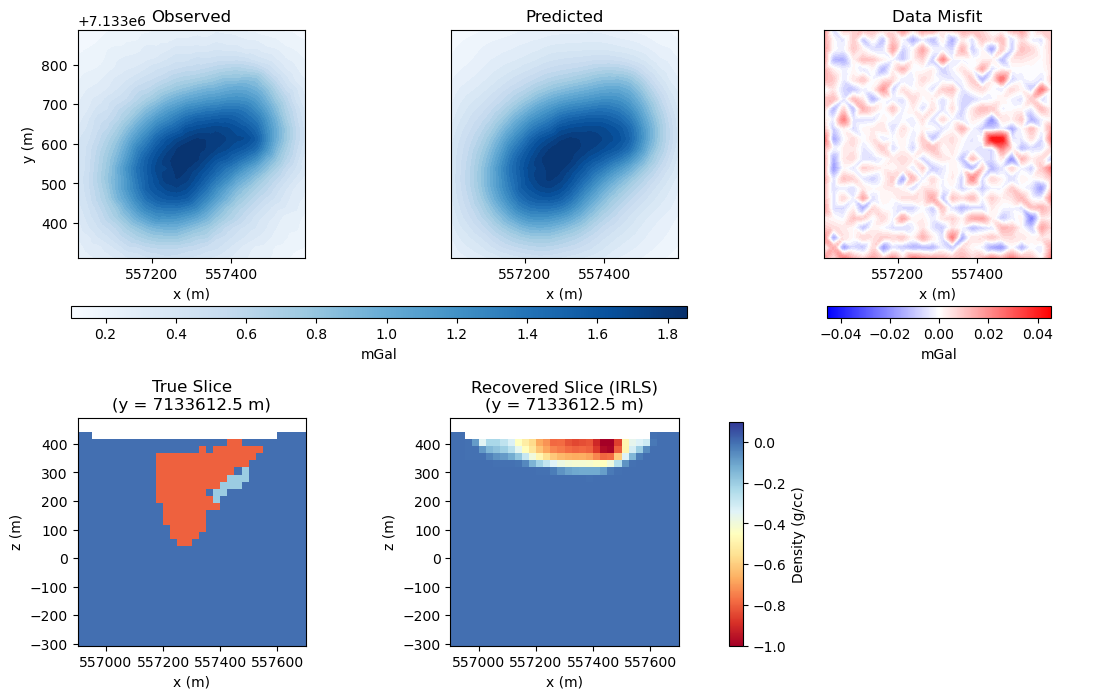

In [ ]:
# Observed / Predicted / Misfit + True/Recovered slices (clean 2x3 layout)
dpred_irls = inv_prob_irls.dpred
data_array_irls = np.c_[dobs, dpred_irls, dobs - dpred_irls]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.7, wspace=0.10)

# Top row (keep three data panels)
ax_data = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
plot_title = ["Observed", "Predicted", "Data Misfit"]

norm_data = mpl.colors.Normalize(
    vmin=np.min(data_array_irls[:, :2]),
    vmax=np.max(data_array_irls[:, :2]),
)
norm_misfit = mpl.colors.Normalize(
    vmin=-np.max(np.abs(data_array_irls[:, 2])),
    vmax=np.max(np.abs(data_array_irls[:, 2])),
)

plot2Ddata(
    receiver_locations,
    data_array_irls[:, 0],
    ax=ax_data[0],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[0].set_title(plot_title[0])
ax_data[0].set_xlabel("x (m)")
ax_data[0].set_ylabel("y (m)")

plot2Ddata(
    receiver_locations,
    data_array_irls[:, 1],
    ax=ax_data[1],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[1].set_title(plot_title[1])
ax_data[1].set_xlabel("x (m)")
ax_data[1].set_yticks([])

plot2Ddata(
    receiver_locations,
    data_array_irls[:, 2],
    ax=ax_data[2],
    ncontour=30,
    contourOpts={"cmap": "bwr", "norm": norm_misfit},
)
ax_data[2].set_title(plot_title[2])
ax_data[2].set_xlabel("x (m)")
ax_data[2].set_yticks([])

# Shared colorbar for observed/predicted data
cax_data = fig.add_axes([0.16, 0.52, 0.44, 0.015])
sm_data = mpl.cm.ScalarMappable(norm=norm_data, cmap=mpl.cm.Blues)
cbar_data = fig.colorbar(sm_data, cax=cax_data, orientation="horizontal")
cbar_data.set_label("mGal")

# Dedicated colorbar for data misfit (third panel)
cax_misfit = fig.add_axes([0.7, 0.52, 0.16, 0.015])
sm_misfit = mpl.cm.ScalarMappable(norm=norm_misfit, cmap=mpl.cm.bwr)
cbar_misfit = fig.colorbar(sm_misfit, cax=cax_misfit, orientation="horizontal")
cbar_misfit.set_label("mGal")

# Bottom row: true and recovered model slices
ax_true = fig.add_subplot(gs[1, 0])
ax_rec = fig.add_subplot(gs[1, 1])
ax_empty = fig.add_subplot(gs[1, 2])
ax_empty.axis("off")

rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2
rho_true_active = rho_true[active_cells]

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

# Fix model color scale across all inversion cases when available
shared_models = [rho_true_active]
for name in [
    "recovered_model",
    "recovered_IRLS_model",
    "recovered_depth_model",
    "recovered_irls_sens_model",
    "recovered_irls_reweighted_model",
]:
    if name in globals():
        shared_models.append(globals()[name])
shared_model_values = np.concatenate(shared_models)
norm_model = mpl.colors.Normalize(
    vmin=np.min(shared_model_values),
    vmax=np.max(shared_model_values),
)

mesh.plot_slice(
    plotting_Map * rho_true_active,
    normal="Y",
    ind=y_idx,
    ax=ax_true,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_true.set_title(f"True Slice\n(y = {y_val:.1f} m)")
ax_true.set_xlabel("x (m)")
ax_true.set_ylabel("z (m)")
ax_true.set_aspect(1)

mesh.plot_slice(
    plotting_Map * recovered_IRLS_model,
    normal="Y",
    ind=y_idx,
    ax=ax_rec,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_rec.set_title(f"Recovered Slice (IRLS)\n(y = {y_val:.1f} m)")
ax_rec.set_xlabel("x (m)")
ax_rec.set_ylabel("z (m)")
ax_rec.set_aspect(1)

# Small model colorbar (does not occupy the last grid cell)
cax_model = fig.add_axes([0.63, 0.11, 0.01, 0.28])
sm_model = mpl.cm.ScalarMappable(norm=norm_model, cmap=mpl.cm.RdYlBu)
cbar_model = fig.colorbar(sm_model, cax=cax_model, orientation="vertical")
cbar_model.set_label("Density (g/cc)")

plt.show()

Plot True, L2 and IRLS Models

In [208]:
# True density model from geology classes
rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2

# active-only version if needed
rho_true_active = rho_true[active_cells]

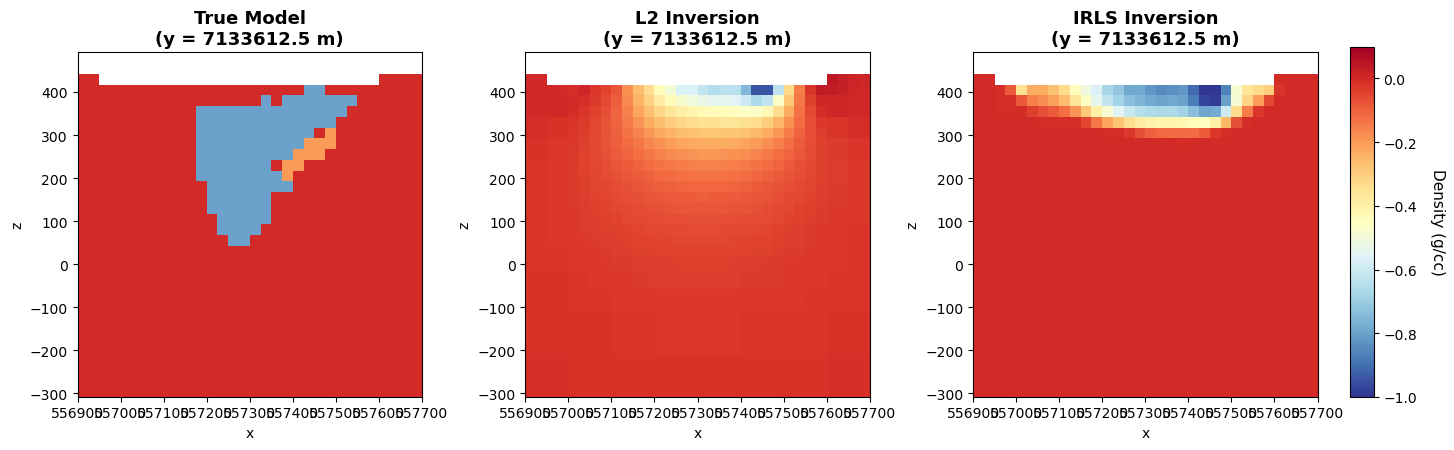

In [209]:
# Plot True, L2 and IRLS density models - compare slices
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# Define the slice index
y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

# Prepare the three models
models = [
    ("True Model", rho_true_active),
    ("L2 Inversion", recovered_model),
    ("IRLS Inversion", recovered_IRLS_model)
]

# Find the common colorbar limits
all_models = np.concatenate([rho_true_active, recovered_model, recovered_IRLS_model])
vmin = np.min(all_models)
vmax = np.max(all_models)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# Plot each model
for i, (title, model_data) in enumerate(models):
    mesh.plot_slice(
        plotting_Map * model_data,
        normal="Y",
        ax=ax[i],
        ind=y_idx,
        grid=False,
        pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm},
    )
    ax[i].set_title(f"{title}\n(y = {y_val:.1f} m)", fontsize=13, fontweight="bold")
    ax[i].set_aspect(1)

# Add a shared colorbar with better positioning
fig.subplots_adjust(right=0.90, wspace=0.3)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    cbar_ax, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label("Density (g/cc)", rotation=270, labelpad=20, fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.show()

## c. Depth-Weighted IRLS

In [210]:
# Depth weights for gravity
depth_weights = utils.depth_weighting(
    mesh,
    receiver_locations,
    active_cells=active_cells,
    exponent=2,
)

# Regularization for depth-weighted IRLS
reg_irls_depth = regularization.Sparse(
    mesh,
    active_cells=active_cells,
    alpha_s=dh**-2,
    alpha_x=1.0,
    alpha_y=1.0,
    alpha_z=1.0,
    reference_model=reference_model,
    reference_model_in_smooth=False,
    norms=[0, 1, 1, 1],
)

reg_irls_depth.set_weights(depth_weights=depth_weights)

# Data misfit for depth-weighted IRLS (use original data_grav)
dmis_irls_depth = data_misfit.L2DataMisfit(data=data_grav, simulation=simulation_grav)

# Optimization for depth-weighted IRLS
opt_irls_depth = optimization.ProjectedGNCG(
    maxIter=100, lower=-1.0, upper=1.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

# Directives for IRLS
starting_beta_irls_depth = directives.BetaEstimate_ByEig(beta0_ratio=10)
update_jacobi_irls_depth = directives.UpdatePreconditioner(update_every_iteration=True)
update_irls_depth = directives.UpdateIRLS(
    cooling_factor=2,
    cooling_rate=1,
    chifact_start=1.0,
    f_min_change=1e-4,
    max_irls_iterations=25,
)

directives_list_irls_depth = [
    update_irls_depth,
    starting_beta_irls_depth,
    update_jacobi_irls_depth,
]

Define and Run the Inversion

In [211]:
# Inverse problem for depth-weighted IRLS
inv_prob_irls_depth = inverse_problem.BaseInvProblem(dmis_irls_depth, reg_irls_depth, opt_irls_depth)
inv_irls_depth = inversion.BaseInversion(inv_prob_irls_depth, directives_list_irls_depth)

recovered_depth_model = inv_irls_depth.run(starting_model)


Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  7.02e+03  4.35e+06  6.73e-08  4.35e+06                         0           inf          inf                
   1  7.02e+03  8.89e+05  1.26e+02  1.78e+06    1.03e+02      0      6        9.03e-03     1.46e+04              
   2  3.51e+03  5.09e+05  2.02e+02  1.22e+06    1.02e+02      0      7        3.86e-03     9.77e+02              
   3  1.76e+03  2.71e+05  2.98e+02  7.93e+05    1.01e+02      0      6        9.50e-03     1.46e+03              
   4  8.78e+02  1.27e+05  4.12e+02  4.88e+05    1.01e+02      0      6        9.77e-03     8.73e+02              
   5  4.39e+02  5.20e+04  5.29e+02  2.84e+05    

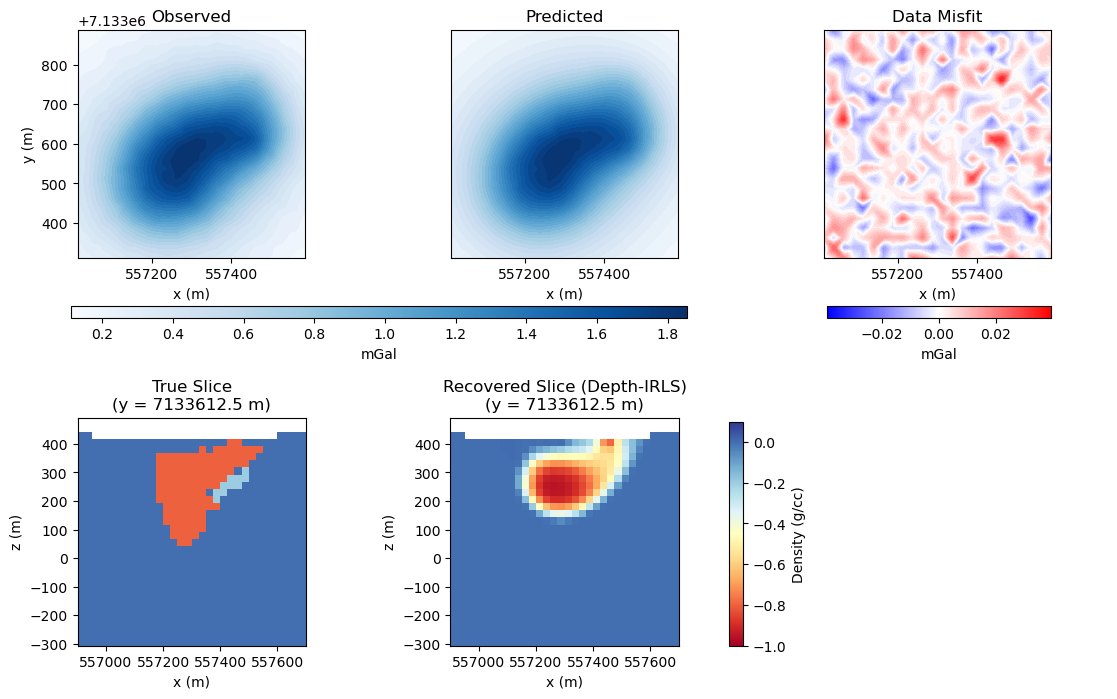

In [ ]:
# Observed / Predicted / Misfit + True/Recovered slices (clean 2x3 layout)
dpred_irls_depth = inv_prob_irls_depth.dpred
data_array_depth = np.c_[dobs, dpred_irls_depth, dobs - dpred_irls_depth]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.7, wspace=0.10)

# Top row (keep three data panels)
ax_data = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
plot_title = ["Observed", "Predicted", "Data Misfit"]

norm_data = mpl.colors.Normalize(
    vmin=np.min(data_array_depth[:, :2]),
    vmax=np.max(data_array_depth[:, :2]),
)
norm_misfit = mpl.colors.Normalize(
    vmin=-np.max(np.abs(data_array_depth[:, 2])),
    vmax=np.max(np.abs(data_array_depth[:, 2])),
)

plot2Ddata(
    receiver_locations,
    data_array_depth[:, 0],
    ax=ax_data[0],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[0].set_title(plot_title[0])
ax_data[0].set_xlabel("x (m)")
ax_data[0].set_ylabel("y (m)")

plot2Ddata(
    receiver_locations,
    data_array_depth[:, 1],
    ax=ax_data[1],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[1].set_title(plot_title[1])
ax_data[1].set_xlabel("x (m)")
ax_data[1].set_yticks([])

plot2Ddata(
    receiver_locations,
    data_array_depth[:, 2],
    ax=ax_data[2],
    ncontour=30,
    contourOpts={"cmap": "bwr", "norm": norm_misfit},
)
ax_data[2].set_title(plot_title[2])
ax_data[2].set_xlabel("x (m)")
ax_data[2].set_yticks([])

# Shared colorbar for observed/predicted data
cax_data = fig.add_axes([0.16, 0.52, 0.44, 0.015])
sm_data = mpl.cm.ScalarMappable(norm=norm_data, cmap=mpl.cm.Blues)
cbar_data = fig.colorbar(sm_data, cax=cax_data, orientation="horizontal")
cbar_data.set_label("mGal")

# Dedicated colorbar for data misfit (third panel)
cax_misfit = fig.add_axes([0.7, 0.52, 0.16, 0.015])
sm_misfit = mpl.cm.ScalarMappable(norm=norm_misfit, cmap=mpl.cm.bwr)
cbar_misfit = fig.colorbar(sm_misfit, cax=cax_misfit, orientation="horizontal")
cbar_misfit.set_label("mGal")

# Bottom row: true and recovered model slices
ax_true = fig.add_subplot(gs[1, 0])
ax_rec = fig.add_subplot(gs[1, 1])
ax_empty = fig.add_subplot(gs[1, 2])
ax_empty.axis("off")

rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2
rho_true_active = rho_true[active_cells]

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

# Fix model color scale across all inversion cases when available
shared_models = [rho_true_active]
for name in [
    "recovered_model",
    "recovered_IRLS_model",
    "recovered_depth_model",
    "recovered_irls_sens_model",
    "recovered_irls_reweighted_model",
]:
    if name in globals():
        shared_models.append(globals()[name])
shared_model_values = np.concatenate(shared_models)
norm_model = mpl.colors.Normalize(
    vmin=np.min(shared_model_values),
    vmax=np.max(shared_model_values),
)

mesh.plot_slice(
    plotting_Map * rho_true_active,
    normal="Y",
    ind=y_idx,
    ax=ax_true,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_true.set_title(f"True Slice\n(y = {y_val:.1f} m)")
ax_true.set_xlabel("x (m)")
ax_true.set_ylabel("z (m)")
ax_true.set_aspect(1)

mesh.plot_slice(
    plotting_Map * recovered_depth_model,
    normal="Y",
    ind=y_idx,
    ax=ax_rec,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_rec.set_title(f"Recovered Slice (Depth-IRLS)\n(y = {y_val:.1f} m)")
ax_rec.set_xlabel("x (m)")
ax_rec.set_ylabel("z (m)")
ax_rec.set_aspect(1)

# Small model colorbar (does not occupy the last grid cell)
cax_model = fig.add_axes([0.63, 0.11, 0.01, 0.28])
sm_model = mpl.cm.ScalarMappable(norm=norm_model, cmap=mpl.cm.RdYlBu)
cbar_model = fig.colorbar(sm_model, cax=cax_model, orientation="vertical")
cbar_model.set_label("Density (g/cc)")

plt.show()

## d. Sensitivity-Weighted IRLS

In [213]:
# =========================
# Sensitivity-weighted IRLS inversion
# =========================

# Data misfit
dmis_irls_sens = data_misfit.L2DataMisfit(
    data=data_grav,
    simulation=simulation_grav,
)

# Sparse regularization
reg_irls_sens = regularization.Sparse(
    mesh,
    active_cells=active_cells,
    alpha_s=dh**-2,
    alpha_x=1.0,
    alpha_y=1.0,
    alpha_z=1.0,
    reference_model=reference_model,
    reference_model_in_smooth=False,
    norms=[0, 1, 1, 1],
)

# Optimization
opt_irls_sens = optimization.ProjectedGNCG(
    maxIter=100,
    lower=-1.0,
    upper=1.0,
    maxIterLS=20,
    maxIterCG=10,
    tolCG=1e-2,
)

# Directives for IRLS
sensitivity_weights_irls_sens = directives.UpdateSensitivityWeights(every_iteration=False)
starting_beta_irls_sens = directives.BetaEstimate_ByEig(beta0_ratio=10)
update_jacobi_irls_sens = directives.UpdatePreconditioner(update_every_iteration=True)
update_irls_sens = directives.UpdateIRLS(
    cooling_factor=2,
    cooling_rate=1,
    chifact_start=1.0,
    f_min_change=1e-4,
    max_irls_iterations=25,
)

directives_list_irls_sens = [
    sensitivity_weights_irls_sens,
    update_irls_sens,
    starting_beta_irls_sens,
    update_jacobi_irls_sens,
]

c:\Users\30562\anaconda3\envs\simpeg_env\Lib\site-packages\simpeg\optimization.py:1535: FutureWarning: InexactCG.tolCG has been deprecated, please use InexactCG.cg_atol. It will be removed in version 0.26.0 of SimPEG.
  self.tolCG = val
c:\Users\30562\anaconda3\envs\simpeg_env\Lib\site-packages\simpeg\optimization.py:1061: FutureWarning: InexactCG.maxIterCG has been deprecated, please use InexactCG.cg_maxiter. It will be removed in version 0.26.0 of SimPEG.
  self.maxIterCG = val


In [214]:
# Inverse problem
inv_prob_irls_sens = inverse_problem.BaseInvProblem(dmis_irls_sens, reg_irls_sens, opt_irls_sens)
inv_irls_sens = inversion.BaseInversion(inv_prob_irls_sens, directives_list_irls_sens)

# Run inversion
recovered_irls_sens_model = inv_irls_sens.run(starting_model)


Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.47e+04  4.35e+06  2.87e-08  4.35e+06                         0           inf          inf                
   1  1.47e+04  9.94e+05  5.70e+01  1.83e+06    1.03e+02      0      10       6.45e-04     1.04e+03              
   2  7.37e+03  6.27e+05  9.21e+01  1.31e+06    1.02e+02      0      10       6.84e-04     1.72e+02              
   3  3.68e+03  3.68e+05  1.42e+02  8.91e+05    1.01e+02      0      10       7.31e-04     1.15e+02              
   4  1.84e+03  1.89e+05  2.10e+02  5.76e+05    1.00e+02      0      10       1.23e-03     1.20e+02              
   5  9.21e+02  8.36e+04  2.90e+02  3.50e+05    

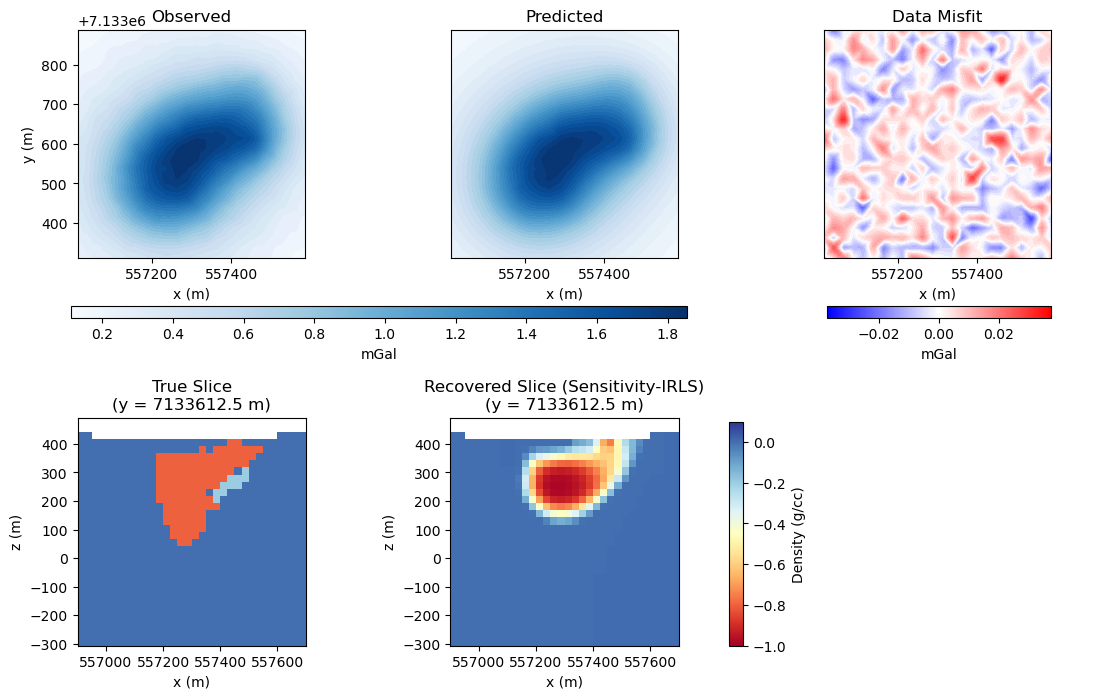

In [220]:
# Observed / Predicted / Misfit + True/Recovered slices (clean 2x3 layout)
dpred_irls_sens = inv_prob_irls_sens.dpred
data_array_sens = np.c_[dobs, dpred_irls_sens, dobs - dpred_irls_sens]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.7, wspace=0.10)

# Top row (keep three data panels)
ax_data = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
plot_title = ["Observed", "Predicted", "Data Misfit"]

norm_data = mpl.colors.Normalize(
    vmin=np.min(data_array_sens[:, :2]),
    vmax=np.max(data_array_sens[:, :2]),
)
norm_misfit = mpl.colors.Normalize(
    vmin=-np.max(np.abs(data_array_sens[:, 2])),
    vmax=np.max(np.abs(data_array_sens[:, 2])),
)

plot2Ddata(
    receiver_locations,
    data_array_sens[:, 0],
    ax=ax_data[0],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[0].set_title(plot_title[0])
ax_data[0].set_xlabel("x (m)")
ax_data[0].set_ylabel("y (m)")

plot2Ddata(
    receiver_locations,
    data_array_sens[:, 1],
    ax=ax_data[1],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[1].set_title(plot_title[1])
ax_data[1].set_xlabel("x (m)")
ax_data[1].set_yticks([])

plot2Ddata(
    receiver_locations,
    data_array_sens[:, 2],
    ax=ax_data[2],
    ncontour=30,
    contourOpts={"cmap": "bwr", "norm": norm_misfit},
)
ax_data[2].set_title(plot_title[2])
ax_data[2].set_xlabel("x (m)")
ax_data[2].set_yticks([])

# Shared colorbar for observed/predicted data
cax_data = fig.add_axes([0.16, 0.52, 0.44, 0.015])
sm_data = mpl.cm.ScalarMappable(norm=norm_data, cmap=mpl.cm.Blues)
cbar_data = fig.colorbar(sm_data, cax=cax_data, orientation="horizontal")
cbar_data.set_label("mGal")

# Dedicated colorbar for data misfit (third panel)
cax_misfit = fig.add_axes([0.7, 0.52, 0.16, 0.015])
sm_misfit = mpl.cm.ScalarMappable(norm=norm_misfit, cmap=mpl.cm.bwr)
cbar_misfit = fig.colorbar(sm_misfit, cax=cax_misfit, orientation="horizontal")
cbar_misfit.set_label("mGal")

# Bottom row: true and recovered model slices
ax_true = fig.add_subplot(gs[1, 0])
ax_rec = fig.add_subplot(gs[1, 1])
ax_empty = fig.add_subplot(gs[1, 2])
ax_empty.axis("off")

rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2
rho_true_active = rho_true[active_cells]

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

# Fix model color scale across all inversion cases when available
shared_models = [rho_true_active]
for name in [
    "recovered_model",
    "recovered_IRLS_model",
    "recovered_depth_model",
    "recovered_irls_sens_model",
    "recovered_irls_reweighted_model",
]:
    if name in globals():
        shared_models.append(globals()[name])
shared_model_values = np.concatenate(shared_models)
norm_model = mpl.colors.Normalize(
    vmin=np.min(shared_model_values),
    vmax=np.max(shared_model_values),
)

mesh.plot_slice(
    plotting_Map * rho_true_active,
    normal="Y",
    ind=y_idx,
    ax=ax_true,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_true.set_title(f"True Slice\n(y = {y_val:.1f} m)")
ax_true.set_xlabel("x (m)")
ax_true.set_ylabel("z (m)")
ax_true.set_aspect(1)

mesh.plot_slice(
    plotting_Map * recovered_irls_sens_model,
    normal="Y",
    ind=y_idx,
    ax=ax_rec,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_rec.set_title(f"Recovered Slice (Sensitivity-IRLS)\n(y = {y_val:.1f} m)")
ax_rec.set_xlabel("x (m)")
ax_rec.set_ylabel("z (m)")
ax_rec.set_aspect(1)

# Small model colorbar (does not occupy the last grid cell)
cax_model = fig.add_axes([0.63, 0.11, 0.01, 0.28])
sm_model = mpl.cm.ScalarMappable(norm=norm_model, cmap=mpl.cm.RdYlBu)
cbar_model = fig.colorbar(sm_model, cax=cax_model, orientation="vertical")
cbar_model.set_label("Density (g/cc)")

plt.show()

## e. Reweighted-data IRLS

Reweighted data (reserved for final inversion only)

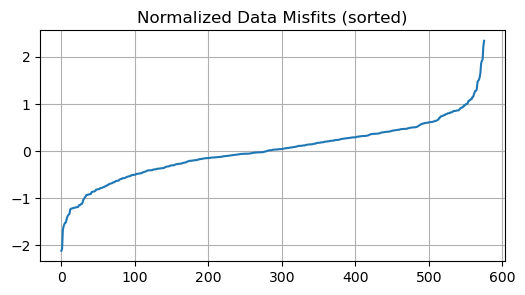

In [215]:
# uncertainty estimate from maximum anomaly
max_anomaly = np.max(np.abs(dobs))
floor = 0.005 * max_anomaly
percent = 0.01
uncertainties = percent * np.abs(dobs) + floor


# Compute normalized data misfits
normalized_data_misfits = (dobs - dpred) / uncertainties


# Plot the normalized data misfits
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111)
ax.plot(np.sort(normalized_data_misfits))
ax.set_title("Normalized Data Misfits (sorted)")
ax.grid()
plt.show(fig)

In [216]:
# Generate new uncertainties
new_uncertainties = uncertainties.copy()

uncertainty_reduce_factor = 2.5
new_uncertainties[np.abs(normalized_data_misfits) > 1] /= uncertainty_reduce_factor # reduce uncertainty for data points with large misfits by a factor of 2.5

In [217]:
# Generate new data object
new_data_object = data.Data(survey=data_grav.survey, dobs=dobs, standard_deviation=new_uncertainties)

In [218]:
# ============================================
# e. Reweighted-data IRLS (use new_data_object)
# ============================================

# Data misfit for reweighted-data IRLS
dmis_irls_reweighted = data_misfit.L2DataMisfit(
    data=new_data_object,
    simulation=simulation_grav,
)

# Sparse regularization
reg_irls_reweighted = regularization.Sparse(
    mesh,
    active_cells=active_cells,
    alpha_s=dh**-2,
    alpha_x=1.0,
    alpha_y=1.0,
    alpha_z=1.0,
    reference_model=reference_model,
    reference_model_in_smooth=False,
    norms=[0, 1, 1, 1],
)

# Optimization
opt_irls_reweighted = optimization.ProjectedGNCG(
    maxIter=100, lower=-1.0, upper=1.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

# Directives for IRLS
starting_beta_irls_reweighted = directives.BetaEstimate_ByEig(beta0_ratio=10)
update_jacobi_irls_reweighted = directives.UpdatePreconditioner(update_every_iteration=True)
update_irls_reweighted = directives.UpdateIRLS(
    cooling_factor=2,
    cooling_rate=1,
    chifact_start=1.0,
    f_min_change=1e-4,
    max_irls_iterations=25,
)

directives_list_irls_reweighted = [
    update_irls_reweighted,
    starting_beta_irls_reweighted,
    update_jacobi_irls_reweighted,
]

# Inverse problem
inv_prob_irls_reweighted = inverse_problem.BaseInvProblem(
    dmis_irls_reweighted, reg_irls_reweighted, opt_irls_reweighted
)
inv_irls_reweighted = inversion.BaseInversion(
    inv_prob_irls_reweighted, directives_list_irls_reweighted
)

# Run inversion
recovered_irls_reweighted_model = inv_irls_reweighted.run(starting_model)


Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  4.92e+02  1.39e+06  7.46e-07  1.39e+06                         0           inf          inf                
   1  4.92e+02  3.29e+05  5.83e+02  6.16e+05    1.05e+02      0      7        5.25e-03     3.83e+03              
   2  2.46e+02  1.88e+05  9.90e+02  4.31e+05    1.04e+02      0      7        6.66e-03     7.79e+02              
   3  1.23e+02  9.54e+04  1.52e+03  2.82e+05    1.03e+02      0      6        8.49e-03     6.05e+02              
   4  6.15e+01  4.26e+04  2.11e+03  1.73e+05    1.02e+02      0      8        5.61e-03     2.30e+02              
   5  3.07e+01  1.69e+04  2.69e+03  9.95e+04    

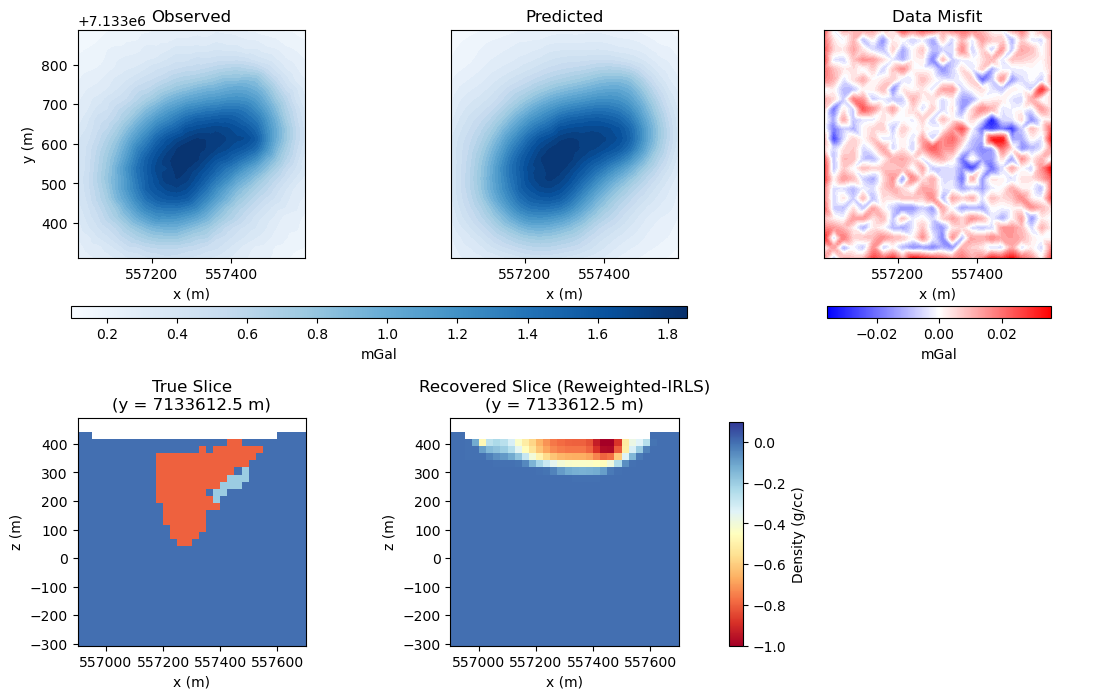

In [221]:
# Observed / Predicted / Misfit + True/Recovered slices (clean 2x3 layout)
dpred_irls_reweighted = inv_prob_irls_reweighted.dpred
data_array_reweighted = np.c_[dobs, dpred_irls_reweighted, dobs - dpred_irls_reweighted]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.7, wspace=0.10)

# Top row (keep three data panels)
ax_data = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
plot_title = ["Observed", "Predicted", "Data Misfit"]

norm_data = mpl.colors.Normalize(
    vmin=np.min(data_array_reweighted[:, :2]),
    vmax=np.max(data_array_reweighted[:, :2]),
)
norm_misfit = mpl.colors.Normalize(
    vmin=-np.max(np.abs(data_array_reweighted[:, 2])),
    vmax=np.max(np.abs(data_array_reweighted[:, 2])),
)

plot2Ddata(
    receiver_locations,
    data_array_reweighted[:, 0],
    ax=ax_data[0],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[0].set_title(plot_title[0])
ax_data[0].set_xlabel("x (m)")
ax_data[0].set_ylabel("y (m)")

plot2Ddata(
    receiver_locations,
    data_array_reweighted[:, 1],
    ax=ax_data[1],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[1].set_title(plot_title[1])
ax_data[1].set_xlabel("x (m)")
ax_data[1].set_yticks([])

plot2Ddata(
    receiver_locations,
    data_array_reweighted[:, 2],
    ax=ax_data[2],
    ncontour=30,
    contourOpts={"cmap": "bwr", "norm": norm_misfit},
)
ax_data[2].set_title(plot_title[2])
ax_data[2].set_xlabel("x (m)")
ax_data[2].set_yticks([])

# Shared colorbar for observed/predicted data
cax_data = fig.add_axes([0.16, 0.52, 0.44, 0.015])
sm_data = mpl.cm.ScalarMappable(norm=norm_data, cmap=mpl.cm.Blues)
cbar_data = fig.colorbar(sm_data, cax=cax_data, orientation="horizontal")
cbar_data.set_label("mGal")

# Dedicated colorbar for data misfit (third panel)
cax_misfit = fig.add_axes([0.7, 0.52, 0.16, 0.015])
sm_misfit = mpl.cm.ScalarMappable(norm=norm_misfit, cmap=mpl.cm.bwr)
cbar_misfit = fig.colorbar(sm_misfit, cax=cax_misfit, orientation="horizontal")
cbar_misfit.set_label("mGal")

# Bottom row: true and recovered model slices
ax_true = fig.add_subplot(gs[1, 0])
ax_rec = fig.add_subplot(gs[1, 1])
ax_empty = fig.add_subplot(gs[1, 2])
ax_empty.axis("off")

rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2
rho_true_active = rho_true[active_cells]

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

# Fix model color scale across all inversion cases when available
shared_models = [rho_true_active]
for name in [
    "recovered_model",
    "recovered_IRLS_model",
    "recovered_depth_model",
    "recovered_irls_sens_model",
    "recovered_irls_reweighted_model",
]:
    if name in globals():
        shared_models.append(globals()[name])
shared_model_values = np.concatenate(shared_models)
norm_model = mpl.colors.Normalize(
    vmin=np.min(shared_model_values),
    vmax=np.max(shared_model_values),
)

mesh.plot_slice(
    plotting_Map * rho_true_active,
    normal="Y",
    ind=y_idx,
    ax=ax_true,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_true.set_title(f"True Slice\n(y = {y_val:.1f} m)")
ax_true.set_xlabel("x (m)")
ax_true.set_ylabel("z (m)")
ax_true.set_aspect(1)

mesh.plot_slice(
    plotting_Map * recovered_irls_reweighted_model,
    normal="Y",
    ind=y_idx,
    ax=ax_rec,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_rec.set_title(f"Recovered Slice (Reweighted-IRLS)\n(y = {y_val:.1f} m)")
ax_rec.set_xlabel("x (m)")
ax_rec.set_ylabel("z (m)")
ax_rec.set_aspect(1)

# Small model colorbar (does not occupy the last grid cell)
cax_model = fig.add_axes([0.63, 0.11, 0.01, 0.28])
sm_model = mpl.cm.ScalarMappable(norm=norm_model, cmap=mpl.cm.RdYlBu)
cbar_model = fig.colorbar(sm_model, cax=cax_model, orientation="vertical")
cbar_model.set_label("Density (g/cc)")

plt.show()

## Final Comparison: All Cases (Same Slice, Shared Colorbar)

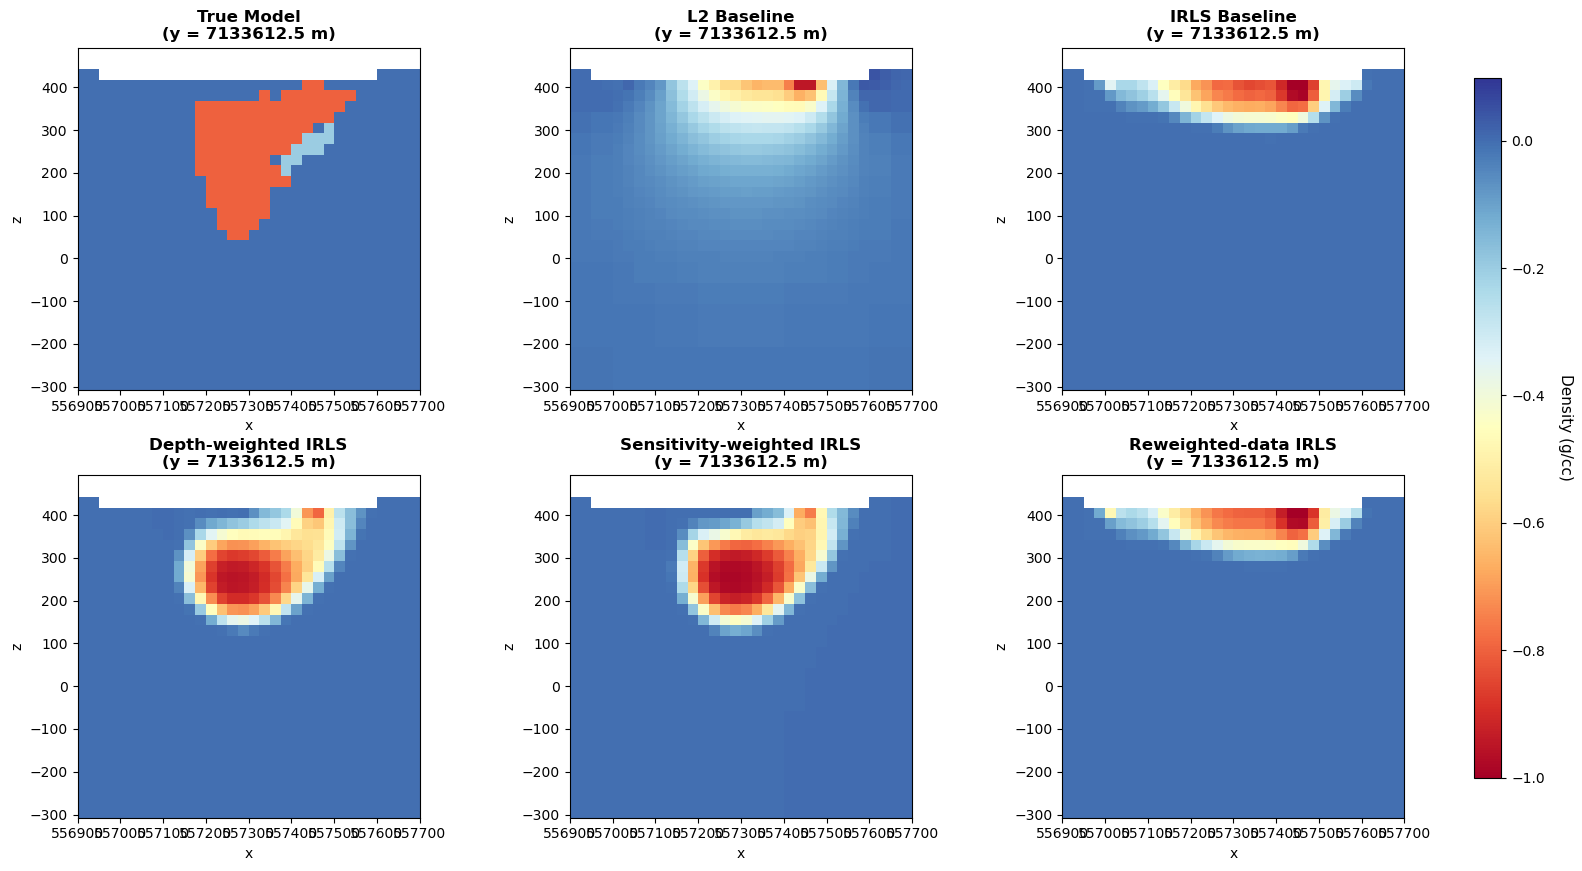

In [219]:
# Plot True + all inversion cases on the same Y-slice with a shared colorbar
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax = ax.ravel()

# Define the slice index
y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

# Assemble all models for comparison
models = [
    ("True Model", rho_true_active),
    ("L2 Baseline", recovered_model),
    ("IRLS Baseline", recovered_IRLS_model),
    ("Depth-weighted IRLS", recovered_depth_model),
    ("Sensitivity-weighted IRLS", recovered_irls_sens_model),
    ("Reweighted-data IRLS", recovered_irls_reweighted_model),
]

# Shared color scale across all panels
all_models = np.concatenate([m for _, m in models])
vmin = np.min(all_models)
vmax = np.max(all_models)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

for i, (title, model_data) in enumerate(models):
    mesh.plot_slice(
        plotting_Map * model_data,
        normal="Y",
        ax=ax[i],
        ind=y_idx,
        grid=False,
        pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm},
    )
    ax[i].set_title(f"{title}\n(y = {y_val:.1f} m)", fontsize=12, fontweight="bold")
    ax[i].set_aspect(1)

# Shared colorbar
fig.subplots_adjust(right=0.90, wspace=0.20, hspace=0.25)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    cbar_ax, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu
)
cbar.set_label("Density (g/cc)", rotation=270, labelpad=20, fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.show()